In [2]:
import os
import json
import time
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else []

import yaml

import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"], check=True)

import ultralytics
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix

print("ultralytics:", ultralytics.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CONFIG_PATHS = {
    "split_csv": "/kaggle/input/notebooks/sumaiyahoque/nb-0-eda-and-data-prep/split.csv",
    "nb1_results_json": "/kaggle/input/notebooks/sumaiyahoque/nb-1-seg-deeplabv3/results.json",
    "nb2_results_json": "/kaggle/input/notebooks/sumaiyahoque/nb-02-seg-segformer-b0/results.json",
    "results_json": "/kaggle/working/results.json",   
    "yolo_dataset_root": "/kaggle/working/yolo_dataset",
}

MASK_THRESHOLD = 127
IMG_SIZE = 512
NUM_CLASSES = 2 

ultralytics: 8.4.95


In [3]:
df = pd.read_csv(CONFIG_PATHS["split_csv"])
print(df["split"].value_counts())
assert set(df["split"].unique()) == {"train", "val", "test"}

split
train    1035
val       318
test      168
Name: count, dtype: int64


In [4]:
all_results = {}
for key in ("nb1_results_json", "nb2_results_json"):
    path = CONFIG_PATHS[key]
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found -- add that notebook's output as a Kaggle "
            f"input data source to this notebook before running Task H."
        )
    with open(path, "r") as f:
        partial = json.load(f)
    all_results.update(partial)
    print(f"Loaded from {path}: {list(partial.keys())}")

with open(CONFIG_PATHS["results_json"], "w") as f:
    json.dump(all_results, f, indent=2)

print("\nWorking results.json currently contains:", list(all_results.keys()))


Loaded from /kaggle/input/notebooks/sumaiyahoque/nb-1-seg-deeplabv3/results.json: ['DeepLabV3']
Loaded from /kaggle/input/notebooks/sumaiyahoque/nb-02-seg-segformer-b0/results.json: ['SegFormer-B0']

Working results.json currently contains: ['DeepLabV3', 'SegFormer-B0']


In [5]:
YOLO_ROOT = Path(CONFIG_PATHS["yolo_dataset_root"])
for split_name in ["train", "val", "test"]:
    (YOLO_ROOT / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "masks" / split_name).mkdir(parents=True, exist_ok=True)

def prepare_yolo_split(df_split, split_name):
    stems = []
    for i, row in df_split.reset_index(drop=True).iterrows():
        img = cv2.imread(row["img_path"])
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask_cls = (mask >= MASK_THRESHOLD).astype(np.uint8)  

        stem = f"{row['patient_id']}_{row['side']}_{i:04d}"
        img_out = YOLO_ROOT / "images" / split_name / f"{stem}.png"
        mask_out = YOLO_ROOT / "masks" / split_name / f"{stem}.png"

        cv2.imwrite(str(img_out), img)
        cv2.imwrite(str(mask_out), mask_cls)
        stems.append((stem, row["img_path"], row["mask_path"]))
    return stems

split_manifests = {}
for split_name in ["train", "val", "test"]:
    split_manifests[split_name] = prepare_yolo_split(df[df["split"] == split_name], split_name)
    print(f"{split_name}: {len(split_manifests[split_name])} pairs written")

stem_to_original = {s: (ip, mp) for split in split_manifests.values() for s, ip, mp in split}

train: 1035 pairs written
val: 318 pairs written
test: 168 pairs written


In [8]:
data_yaml = {
    "path": str(YOLO_ROOT),
    "train": "images/train",
    "val": "images/val",
    "masks_dir": "masks",
    "names": {0: "background", 1: "lesion"},
}
data_yaml_path = YOLO_ROOT / "data.yaml"
with open(data_yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(data_yaml_path.read_text())


path: /kaggle/working/yolo_dataset
train: images/train
val: images/val
masks_dir: masks
names:
  0: background
  1: lesion



In [9]:
model = YOLO("yolo26n-sem.pt")

In [14]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch 
torch.cuda.is_available()

True

In [15]:
TRAIN_CONFIG = {
    "model": "YOLOv26n-Sem (yolo26n-sem.pt, Cityscapes-pretrained)",
    "num_classes": NUM_CLASSES,
    "input_size": IMG_SIZE,
    "batch_size": 8,
    "epochs": 50,
    "optimizer": "AdamW",       
    "learning_rate": 1e-3,      
    "seed": SEED,
    "loss_function": "Ultralytics built-in semantic segmentation loss (weighted CE + Dice internally)",
}
print(json.dumps(TRAIN_CONFIG, indent=2))

start_time = time.time()
train_results = model.train(
    data=str(data_yaml_path),
    epochs=TRAIN_CONFIG["epochs"],
    imgsz=TRAIN_CONFIG["input_size"],
    batch=TRAIN_CONFIG["batch_size"],
    optimizer=TRAIN_CONFIG["optimizer"],
    lr0=TRAIN_CONFIG["learning_rate"],
    seed=TRAIN_CONFIG["seed"],
    project="/kaggle/working",
    name="yolo26n_sem_run",
    patience=50,  
    verbose=True,
)
total_train_time = time.time() - start_time
print(f"Training complete in {total_train_time/60:.1f} min")
best_ckpt = Path("/kaggle/working/yolo26n_sem_run/weights/best.pt")
model = YOLO(str(best_ckpt))
print(f"Loaded best checkpoint: {best_ckpt}")
results_csv = pd.read_csv("/kaggle/working/yolo26n_sem_run/results.csv")
print(results_csv.columns.tolist())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
loss_cols = [c for c in results_csv.columns if "loss" in c.lower()]
for c in loss_cols:
    axes[0].plot(results_csv[c], label=c)
axes[0].set_title("Training losses"); axes[0].legend(fontsize=7)
miou_cols = [c for c in results_csv.columns if "miou" in c.lower() or "iou" in c.lower()]
for c in miou_cols:
    axes[1].plot(results_csv[c], label=c, color="green")
axes[1].set_title("mIoU"); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

{
  "model": "YOLOv26n-Sem (yolo26n-sem.pt, Cityscapes-pretrained)",
  "num_classes": 2,
  "input_size": 512,
  "batch_size": 8,
  "epochs": 50,
  "optimizer": "AdamW",
  "learning_rate": 0.001,
  "seed": 42,
  "loss_function": "Ultralytics built-in semantic segmentation loss (weighted CE + Dice internally)"
}
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/yolo26n_sem_run/weights/best.pt'

In [16]:
def compute_miou_np(preds, targets, num_classes=NUM_CLASSES):
    ious = []
    for c in range(num_classes):
        pred_c = (preds == c)
        target_c = (targets == c)
        intersection = (pred_c & target_c).sum()
        union = (pred_c | target_c).sum()
        if union == 0:
            continue
        ious.append(intersection / union)
    return float(np.mean(ious)) if ious else 0.0


test_stems = split_manifests["test"]
all_preds, all_targets = [], []
per_image_iou = []
cm_total = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

test_image_paths = [str(YOLO_ROOT / "images" / "test" / f"{stem}.png") for stem, _, _ in test_stems]

for stem, orig_img_path, orig_mask_path in tqdm(test_stems, desc="Test evaluation"):
    img_path = str(YOLO_ROOT / "images" / "test" / f"{stem}.png")
    gt_mask = cv2.imread(str(YOLO_ROOT / "masks" / "test" / f"{stem}.png"), cv2.IMREAD_GRAYSCALE)

    result = model.predict(img_path, imgsz=IMG_SIZE, verbose=False)[0]
    pred_mask = result.semantic_mask.data
    if hasattr(pred_mask, "cpu"):
        pred_mask = pred_mask.cpu().numpy()
    pred_mask = np.asarray(pred_mask)

    if pred_mask.shape != gt_mask.shape:
        pred_mask = cv2.resize(pred_mask.astype(np.uint8), (gt_mask.shape[1], gt_mask.shape[0]),
                                interpolation=cv2.INTER_NEAREST)

    iou = compute_miou_np(pred_mask, gt_mask)
    per_image_iou.append((orig_img_path, iou))
    cm_total += confusion_matrix(gt_mask.flatten(), pred_mask.flatten(), labels=list(range(NUM_CLASSES)))

    all_preds.append(pred_mask.flatten())
    all_targets.append(gt_mask.flatten())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

per_class_iou = []
for c in range(NUM_CLASSES):
    pred_c = (all_preds == c)
    target_c = (all_targets == c)
    intersection = (pred_c & target_c).sum()
    union = (pred_c | target_c).sum()
    per_class_iou.append(intersection / union if union > 0 else 0.0)
miou = float(np.mean(per_class_iou))

overall_pixel_acc = (all_preds == all_targets).mean()
per_class_acc = []
for c in range(NUM_CLASSES):
    target_c = (all_targets == c)
    if target_c.sum() == 0:
        continue
    per_class_acc.append((all_preds[target_c] == c).mean())
mean_pixel_acc = float(np.mean(per_class_acc))

dice_scores = []
for c in range(NUM_CLASSES):
    pred_c = (all_preds == c)
    target_c = (all_targets == c)
    intersection = (pred_c & target_c).sum()
    dice = (2 * intersection) / (pred_c.sum() + target_c.sum() + 1e-8)
    dice_scores.append(dice)

test_results = {
    "mIoU": miou,
    "per_class_iou": [float(x) for x in per_class_iou],
    "overall_pixel_accuracy": float(overall_pixel_acc),
    "mean_pixel_accuracy": mean_pixel_acc,
    "dice_per_class": [float(x) for x in dice_scores],
    "mean_dice": float(np.mean(dice_scores)),
    "confusion_matrix": cm_total.tolist(),
    "per_image_iou": per_image_iou,
}

print(f"mIoU: {test_results['mIoU']:.4f}")
print(f"Per-class IoU (bg, lesion): {test_results['per_class_iou']}")
print(f"Overall pixel accuracy: {test_results['overall_pixel_accuracy']:.4f}")
print(f"Mean pixel accuracy: {test_results['mean_pixel_accuracy']:.4f}")
print(f"Mean Dice: {test_results['mean_dice']:.4f}")

Test evaluation:   0%|          | 0/168 [00:00<?, ?it/s]

mIoU: 0.8402
Per-class IoU (bg, lesion): [0.9927284497951668, 0.6877043350995099]
Overall pixel accuracy: 0.9928
Mean pixel accuracy: 0.8778
Mean Dice: 0.9057


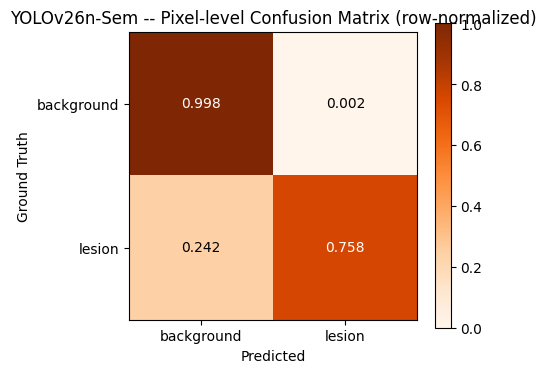

In [17]:
cm = np.array(test_results["confusion_matrix"])
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_norm, cmap="Oranges", vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(["background", "lesion"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["background", "lesion"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Ground Truth")
ax.set_title("YOLOv26n-Sem -- Pixel-level Confusion Matrix (row-normalized)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_norm[i,j]:.3f}", ha="center", va="center",
                 color="white" if cm_norm[i, j] > 0.5 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

Worst-performing test images (lowest per-image IoU):
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0007-00015.jpg: IoU=0.5014
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0011-00002.jpg: IoU=0.5603
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0011-00001.jpg: IoU=0.5610
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0011-00004.jpg: IoU=0.5627
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0011-00003.jpg: IoU=0.5635
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0011-00005.jpg: IoU=0.5686


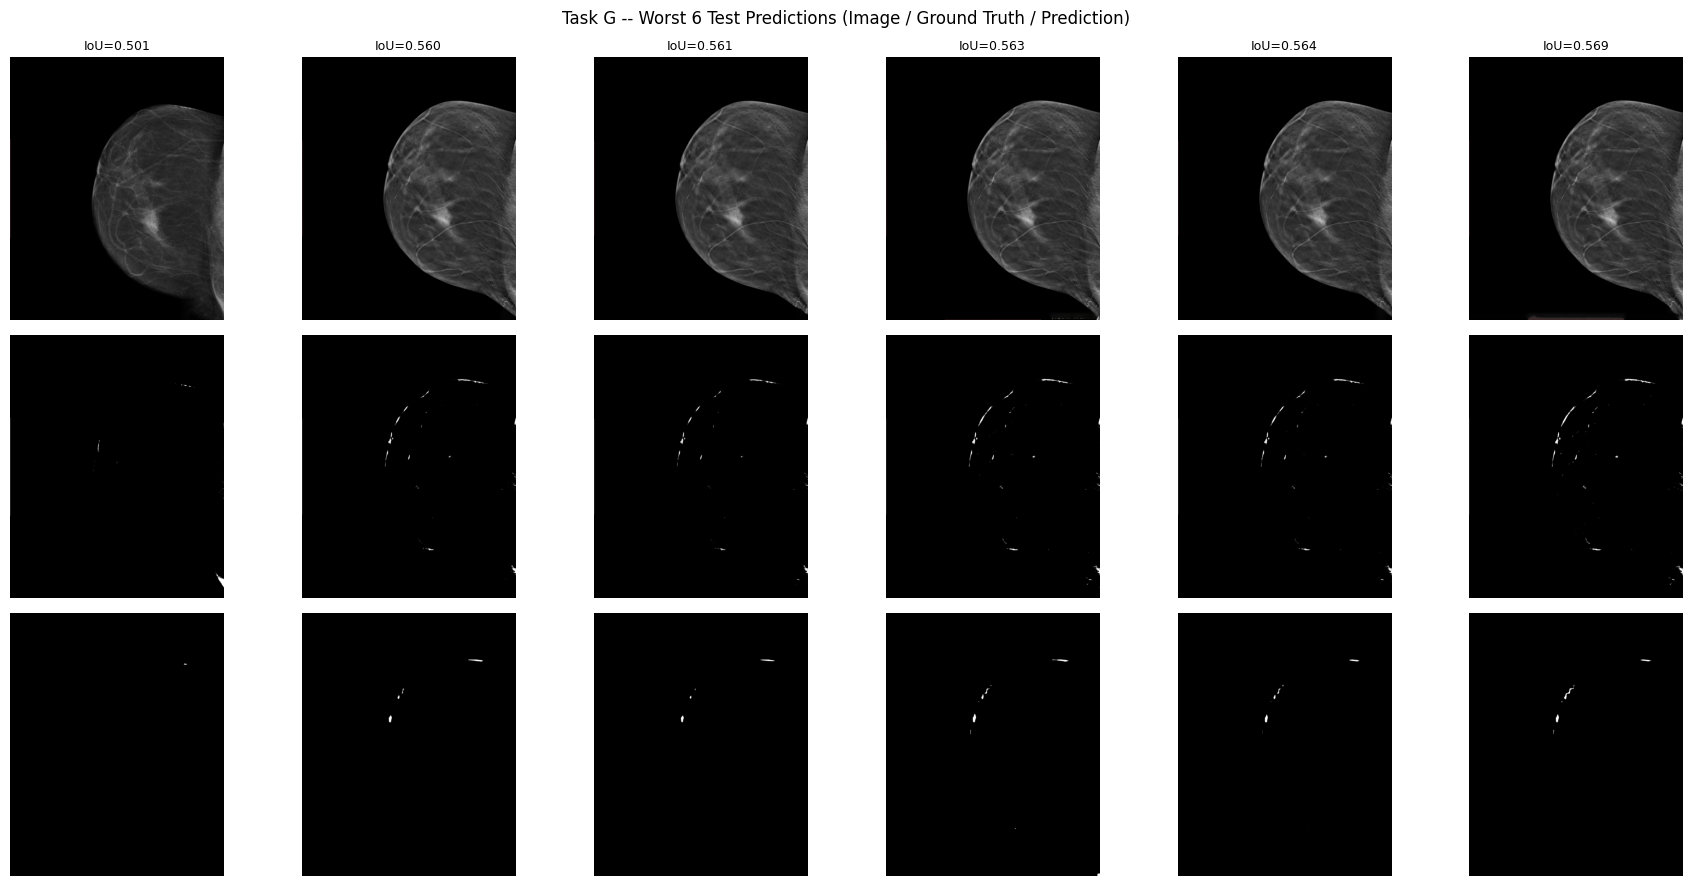

In [18]:
per_image_iou_sorted = sorted(test_results["per_image_iou"], key=lambda x: x[1])
worst_n = 6
worst_cases = per_image_iou_sorted[:worst_n]

print("Worst-performing test images (lowest per-image IoU):")
for path, iou in worst_cases:
    print(f"  {path}: IoU={iou:.4f}")

fig, axes = plt.subplots(3, worst_n, figsize=(3 * worst_n, 9))
for col, (orig_img_path, iou) in enumerate(worst_cases):
    stem = [s for s, ip, mp in test_stems if ip == orig_img_path][0]
    img = cv2.cvtColor(cv2.imread(str(YOLO_ROOT / "images" / "test" / f"{stem}.png")), cv2.COLOR_BGR2RGB)
    gt_mask = cv2.imread(str(YOLO_ROOT / "masks" / "test" / f"{stem}.png"), cv2.IMREAD_GRAYSCALE)

    result = model.predict(str(YOLO_ROOT / "images" / "test" / f"{stem}.png"), imgsz=IMG_SIZE, verbose=False)[0]
    pred_mask = np.asarray(result.semantic_mask.data.cpu() if hasattr(result.semantic_mask.data, "cpu")
                            else result.semantic_mask.data)

    axes[0, col].imshow(img); axes[0, col].set_title(f"IoU={iou:.3f}", fontsize=9); axes[0, col].axis("off")
    axes[1, col].imshow(gt_mask, cmap="gray"); axes[1, col].axis("off")
    axes[2, col].imshow(pred_mask, cmap="gray"); axes[2, col].axis("off")

plt.suptitle("Task G -- Worst 6 Test Predictions (Image / Ground Truth / Prediction)")
plt.tight_layout()
plt.show()

In [19]:
off_diag_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j:
            off_diag_pairs.append(((i, j), cm[i, j]))
off_diag_pairs.sort(key=lambda x: -x[1])

class_names = ["background", "lesion"]
print("Most confused class pairs (ground_truth -> predicted, pixel count):")
for (i, j), count in off_diag_pairs:
    print(f"  {class_names[i]} -> {class_names[j]}: {count:,} pixels")

model_summary = {
    "model_name": "YOLOv26n-Sem",
    "config": TRAIN_CONFIG,
    "actual_epochs_trained": TRAIN_CONFIG["epochs"],
    "total_train_time_minutes": round(total_train_time / 60, 2),
    "test_metrics": {
        "mIoU": test_results["mIoU"],
        "per_class_iou": test_results["per_class_iou"],
        "overall_pixel_accuracy": test_results["overall_pixel_accuracy"],
        "mean_pixel_accuracy": test_results["mean_pixel_accuracy"],
        "mean_dice": test_results["mean_dice"],
        "dice_per_class": test_results["dice_per_class"],
    },
}

if os.path.exists(CONFIG_PATHS["results_json"]):
    with open(CONFIG_PATHS["results_json"], "r") as f:
        all_results = json.load(f)
else:
    all_results = {}

all_results["YOLOv26-Sem"] = model_summary

with open(CONFIG_PATHS["results_json"], "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Saved YOLOv26-Sem results to {CONFIG_PATHS['results_json']}")
print("\nModels currently in results.json:", list(all_results.keys()))

Most confused class pairs (ground_truth -> predicted, pixel count):
  lesion -> background: 4,011,460 pixels
  background -> lesion: 1,688,810 pixels
Saved YOLOv26-Sem results to /kaggle/working/results.json

Models currently in results.json: ['DeepLabV3', 'SegFormer-B0', 'YOLOv26-Sem']


In [20]:
with open(CONFIG_PATHS["results_json"], "r") as f:
    all_results = json.load(f)

assert len(all_results) == 3, (
    f"Expected 3 models in results.json, found {len(all_results)}: {list(all_results.keys())}. "
    "Make sure NB1 and NB2's results.json entries were merged into this notebook's "
    "results.json before running Task H."
)

summary_rows = []
for model_name, info in all_results.items():
    tm = info["test_metrics"]
    summary_rows.append({
        "Model": model_name,
        "mIoU": round(tm["mIoU"], 4),
        "BG IoU": round(tm["per_class_iou"][0], 4),
        "Lesion IoU": round(tm["per_class_iou"][1], 4),
        "Overall Pixel Acc": round(tm["overall_pixel_accuracy"], 4),
        "Mean Pixel Acc": round(tm["mean_pixel_accuracy"], 4),
        "Mean Dice": round(tm["mean_dice"], 4),
        "Train Time (min)": info["total_train_time_minutes"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("mIoU", ascending=False).reset_index(drop=True)
summary_df

,Model,mIoU,BG IoU,Lesion IoU,Overall Pixel Acc,Mean Pixel Acc,Mean Dice,Train Time (min)
0,SegFormer-B0,0.8758,0.9938,0.7579,0.9939,0.9664,0.9296,58.25
1,DeepLabV3,0.8520,0.9924,0.7116,0.9925,0.9500,0.9138,357.92
2,YOLOv26-Sem,0.8402,0.9927,0.6877,0.9928,0.8778,0.9057,79.22


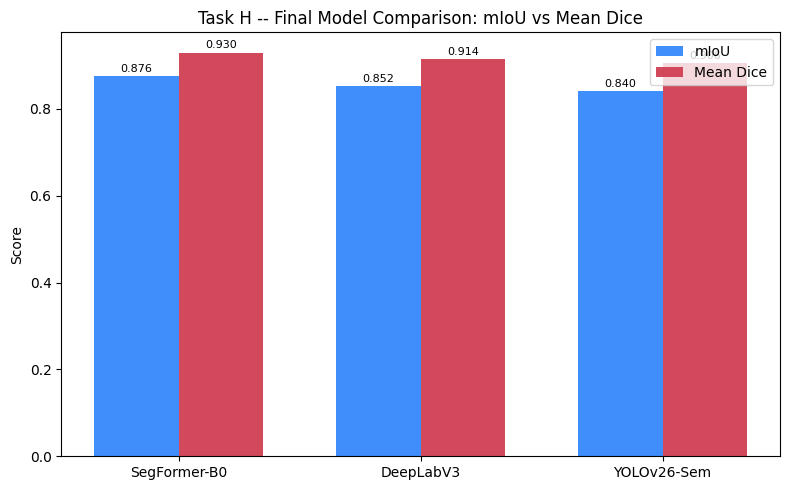

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summary_df))
width = 0.35
ax.bar(x - width/2, summary_df["mIoU"], width, label="mIoU", color="#3f8efc")
ax.bar(x + width/2, summary_df["Mean Dice"], width, label="Mean Dice", color="#d1495b")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Model"])
ax.set_ylabel("Score")
ax.set_title("Task H -- Final Model Comparison: mIoU vs Mean Dice")
ax.legend()
for i, (miou, dice) in enumerate(zip(summary_df["mIoU"], summary_df["Mean Dice"])):
    ax.text(i - width/2, miou + 0.01, f"{miou:.3f}", ha="center", fontsize=8)
    ax.text(i + width/2, dice + 0.01, f"{dice:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

In [26]:
DEEPLABV3_CKPT = "/kaggle/input/notebooks/sumaiyahoque/nb-1-seg-deeplabv3/deeplabv3_best.pt"
SEGFORMER_CKPT = "/kaggle/input/notebooks/sumaiyahoque/nb-02-seg-segformer-b0/segformer_best.pt"

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.segmentation import deeplabv3_resnet50
from transformers import SegformerForSemanticSegmentation

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

In [ ]:
deeplab_model = deeplabv3_resnet50(weights=None, aux_loss=True)
deeplab_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
if deeplab_model.aux_classifier is not None:
    deeplab_model.aux_classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
deeplab_model.load_state_dict(torch.load(DEEPLABV3_CKPT, map_location=DEVICE))
deeplab_model = deeplab_model.to(DEVICE).eval()

segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512", num_labels=NUM_CLASSES, ignore_mismatched_sizes=True
)
segformer_model.load_state_dict(torch.load(SEGFORMER_CKPT, map_location=DEVICE))
segformer_model = segformer_model.to(DEVICE).eval()

n_show = 5
show_cases = per_image_iou_sorted[:n_show]  

fig, axes = plt.subplots(5, n_show, figsize=(3 * n_show, 15))
row_labels = ["Image", "Ground Truth", "DeepLabV3", "SegFormer-B0", "YOLOv26-Sem"]

for col, (orig_img_path, _) in enumerate(show_cases):
    stem = [s for s, ip, mp in test_stems if ip == orig_img_path][0]
    orig_mask_path = [mp for s, ip, mp in test_stems if ip == orig_img_path][0]

    img = cv2.cvtColor(cv2.imread(orig_img_path), cv2.COLOR_BGR2RGB)
    gt_mask = cv2.imread(orig_mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = (gt_mask >= MASK_THRESHOLD).astype(np.uint8)

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    gt_resized = cv2.resize(gt_mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    tensor_img = (img_resized.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
    tensor_img = torch.from_numpy(tensor_img.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        dl_pred = deeplab_model(tensor_img)["out"].argmax(dim=1).squeeze(0).cpu().numpy()
        sf_logits = segformer_model(pixel_values=tensor_img).logits
        sf_logits = F.interpolate(sf_logits, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        sf_pred = sf_logits.argmax(dim=1).squeeze(0).cpu().numpy()

    yolo_result = model.predict(str(YOLO_ROOT / "images" / "test" / f"{stem}.png"), imgsz=IMG_SIZE, verbose=False)[0]
    yolo_pred = np.asarray(yolo_result.semantic_mask.data.cpu() if hasattr(yolo_result.semantic_mask.data, "cpu")
                            else yolo_result.semantic_mask.data)
    if yolo_pred.shape != gt_resized.shape:
        yolo_pred = cv2.resize(yolo_pred.astype(np.uint8), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    axes[0, col].imshow(img_resized); axes[0, col].axis("off")
    axes[1, col].imshow(gt_resized, cmap="gray"); axes[1, col].axis("off")
    axes[2, col].imshow(dl_pred, cmap="gray"); axes[2, col].axis("off")
    axes[3, col].imshow(sf_pred, cmap="gray"); axes[3, col].axis("off")
    axes[4, col].imshow(yolo_pred, cmap="gray"); axes[4, col].axis("off")

for r, label in enumerate(row_labels):
    axes[r, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=10)

plt.suptitle("Task H -- Qualitative Comparison: All 3 Models on the Same Test Images")
plt.tight_layout()
plt.show()

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

In [25]:
print(summary_df.to_string(index=False))

       Model   mIoU  BG IoU  Lesion IoU  Overall Pixel Acc  Mean Pixel Acc  Mean Dice  Train Time (min)
SegFormer-B0 0.8758  0.9938      0.7579             0.9939          0.9664     0.9296             58.25
   DeepLabV3 0.8520  0.9924      0.7116             0.9925          0.9500     0.9138            357.92
 YOLOv26-Sem 0.8402  0.9927      0.6877             0.9928          0.8778     0.9057             79.22
